In [6]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


In [7]:
# Download required NLTK resources

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...


True

In [8]:
# Load the dataset

df = pd.read_csv("youtube.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (161470, 18)


,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False


In [9]:
# Remove duplicate rows

df = df.drop_duplicates()

# Convert dates into datetime format

df["publish_date"] = pd.to_datetime(
    df["publish_date"],
    dayfirst=True,
    errors="coerce"
)

# Remove rows having invalid publish dates

df = df.dropna(subset=["publish_date"])

# Reset index

df.reset_index(drop=True, inplace=True)

print("Cleaned Dataset Shape:", df.shape)

df.head()

Cleaned Dataset Shape: (161470, 18)


,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False


In [10]:
# Display numerical summary

df.describe()

,index,category_id,publish_date,views,likes,dislikes,comment_count
count,161470.00000,161470.000000,161470,1.614700e+05,1.614700e+05,1.614700e+05,1.614700e+05
mean,80734.50000,19.461151,2018-02-11 12:09:47.522140160,2.419854e+06,6.566194e+04,3.490153e+03,7.035494e+03
min,0.00000,1.000000,2006-07-23 00:00:00,2.230000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,40367.25000,15.000000,2017-12-29 00:00:00,1.015382e+05,1.975000e+03,8.500000e+01,2.790000e+02
50%,80734.50000,23.000000,2018-02-19 00:00:00,3.847395e+05,9.840000e+03,3.480000e+02,1.144000e+03
75%,121101.75000,24.000000,2018-04-16 00:00:00,1.339528e+06,4.006275e+04,1.350000e+03,4.144750e+03
max,161469.00000,44.000000,2018-06-14 00:00:00,4.245389e+08,5.613827e+06,1.944971e+06,1.626501e+06
std,46612.51832,7.432001,NaN,1.043749e+07,2.260617e+05,3.114779e+04,3.404121e+04


In [11]:
# Fill missing values in text columns

df["title"] = df["title"].fillna("")
df["tags"] = df["tags"].fillna("")
df["channel_title"] = df["channel_title"].fillna("Unknown")

# Fill missing numeric values

numeric_columns = ["views", "likes", "dislikes", "comment_count"]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
index                     0
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_date              0
time_frame                0
published_day_of_week     0
publish_country           0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
dtype: int64


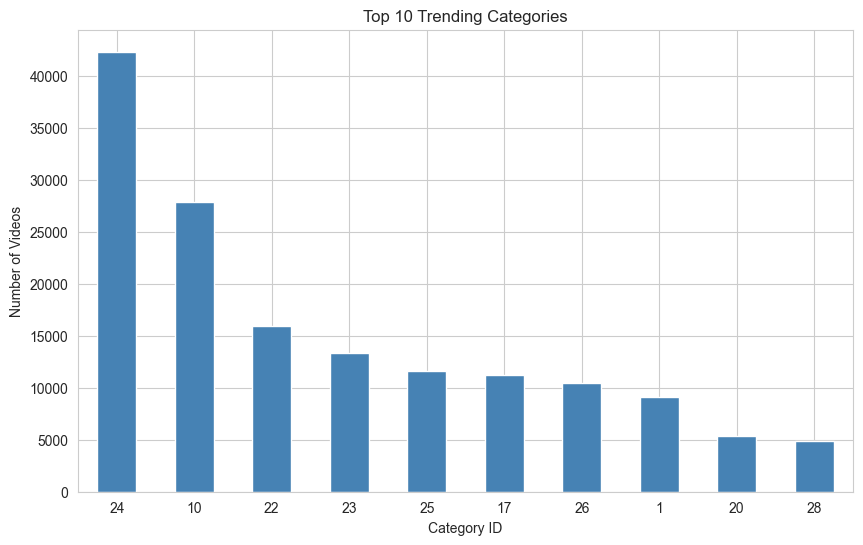

In [12]:
# Top categories by number of videos

plt.figure(figsize=(10,6))

df["category_id"].value_counts().head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Trending Categories")
plt.xlabel("Category ID")
plt.ylabel("Number of Videos")
plt.xticks(rotation=0)

plt.show()

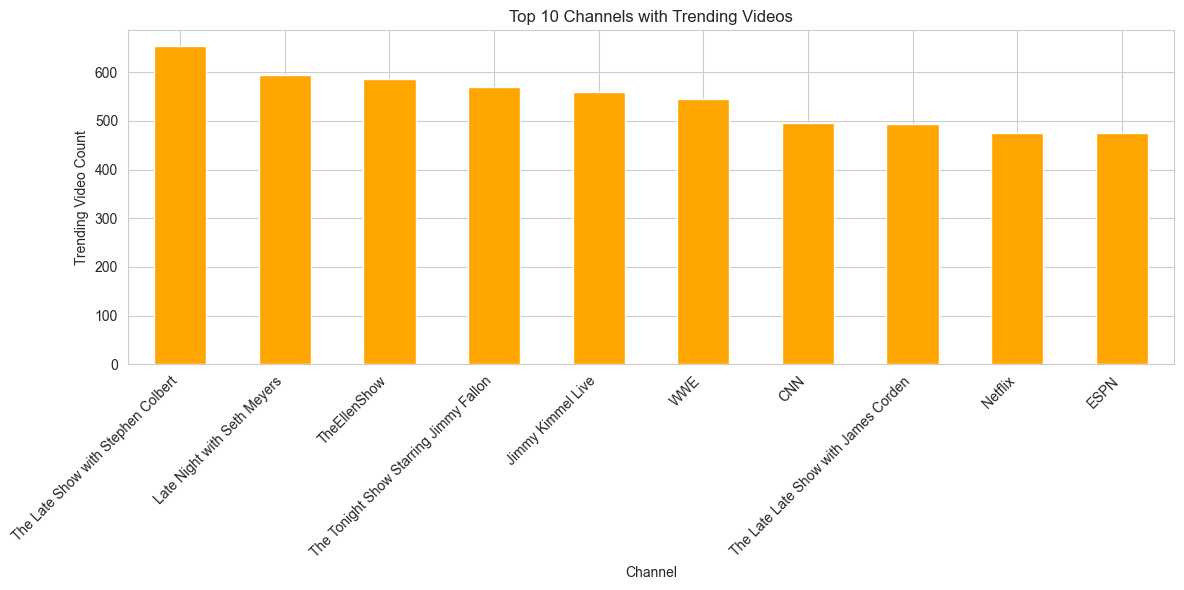

In [13]:
# Most frequently trending channels

top_channels = (
    df["channel_title"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_channels.plot(kind="bar", color="orange")

plt.title("Top 10 Channels with Trending Videos")
plt.xlabel("Channel")
plt.ylabel("Trending Video Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

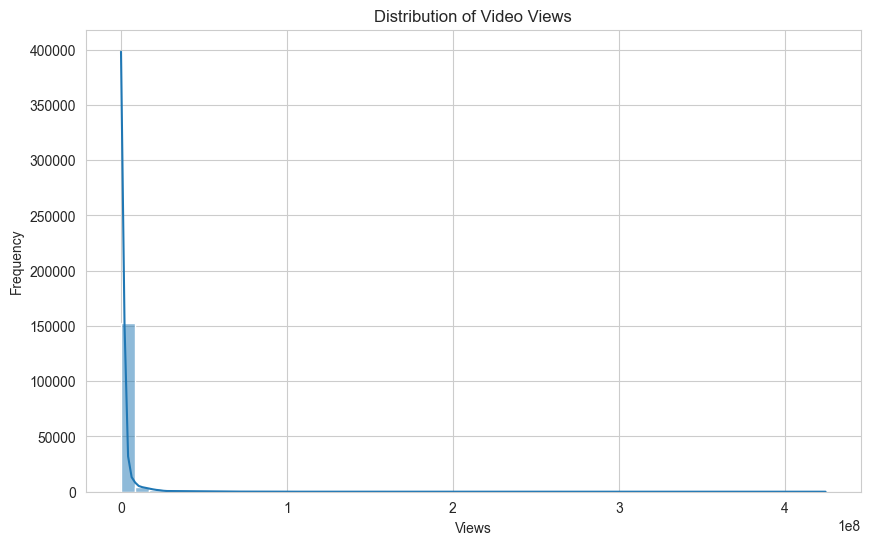

In [14]:
# Distribution of video views

plt.figure(figsize=(10,6))

sns.histplot(df["views"], bins=50, kde=True)

plt.title("Distribution of Video Views")
plt.xlabel("Views")
plt.ylabel("Frequency")

plt.show()

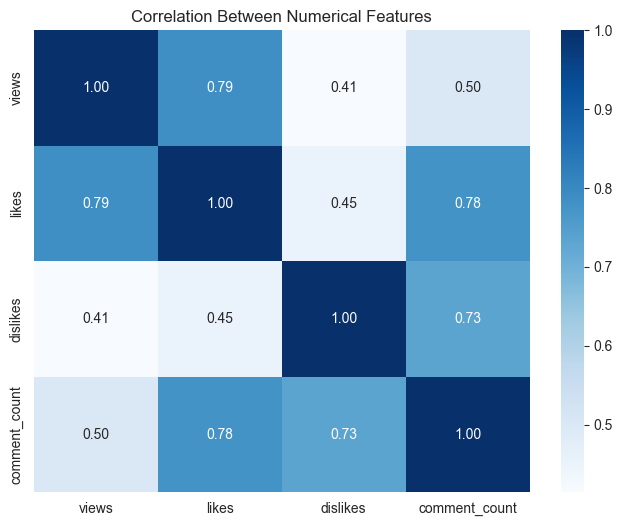

In [15]:
# Correlation between numerical features

plt.figure(figsize=(8,6))

correlation = df[["views", "likes", "dislikes", "comment_count"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.show()

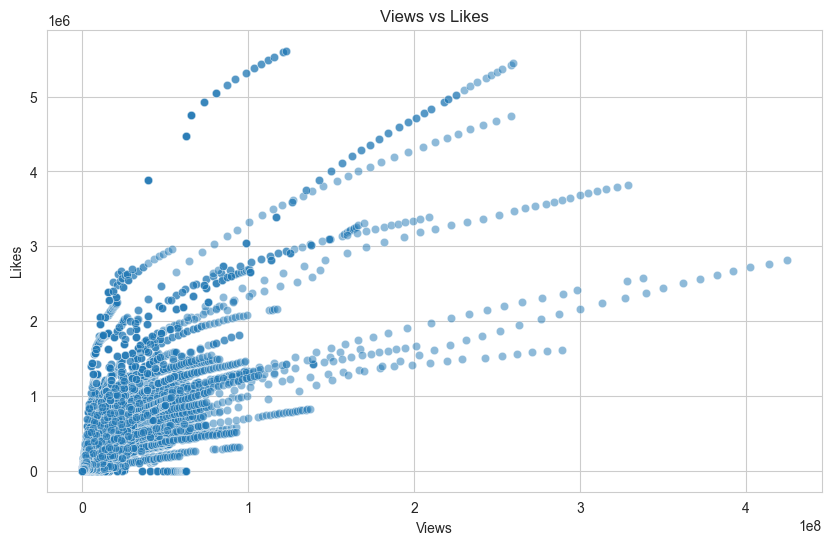

In [16]:
# Relationship between views and likes

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="views",
    y="likes",
    alpha=0.5
)

plt.title("Views vs Likes")
plt.xlabel("Views")
plt.ylabel("Likes")

plt.show()

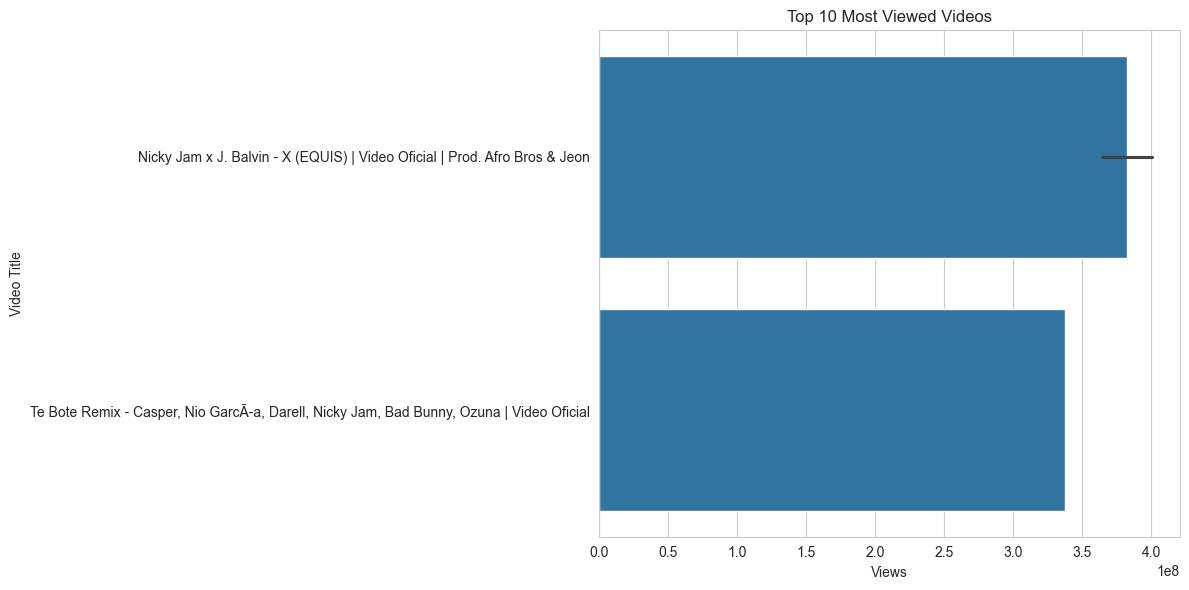

In [17]:
# Display the most viewed videos

top_videos = (
    df[["title", "views"]]
    .sort_values(by="views", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_videos,
    x="views",
    y="title"
)

plt.title("Top 10 Most Viewed Videos")
plt.xlabel("Views")
plt.ylabel("Video Title")

plt.tight_layout()
plt.show()

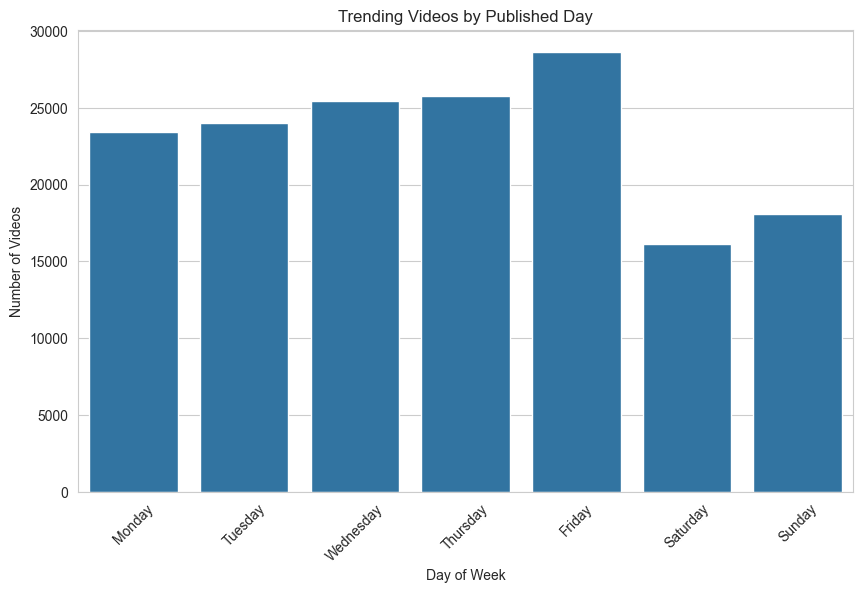

In [18]:
# Number of trending videos uploaded on each day

plt.figure(figsize=(10,6))

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sns.countplot(
    data=df,
    x="published_day_of_week",
    order=day_order
)

plt.title("Trending Videos by Published Day")
plt.xlabel("Day of Week")
plt.ylabel("Number of Videos")

plt.xticks(rotation=45)

plt.show()

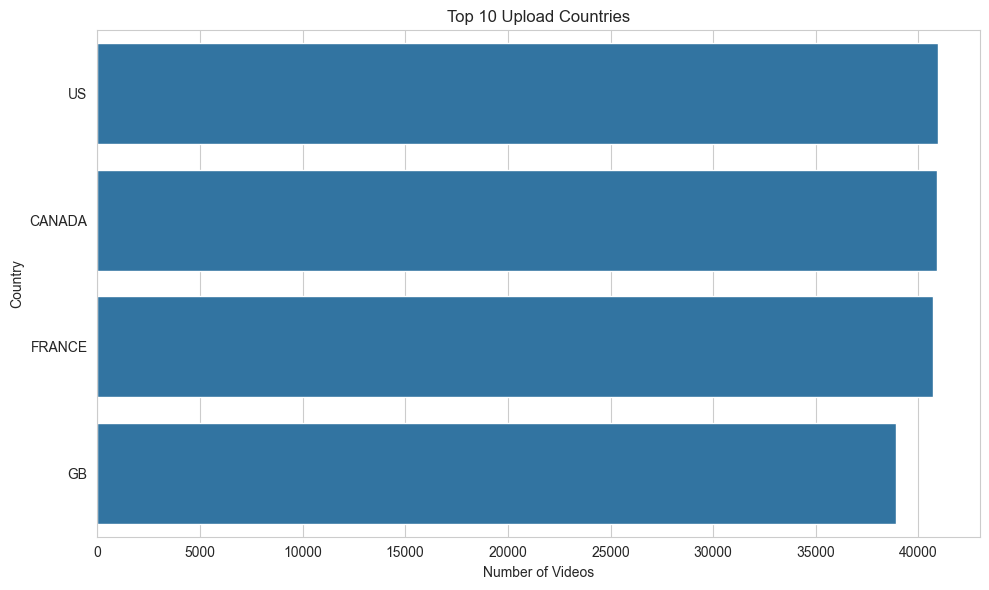

In [19]:
# Top upload countries

plt.figure(figsize=(10,6))

country_count = (
    df["publish_country"]
    .value_counts()
    .head(10)
)

sns.barplot(
    x=country_count.values,
    y=country_count.index
)

plt.title("Top 10 Upload Countries")
plt.xlabel("Number of Videos")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [20]:
# Combine title and tags for text analysis

df["text"] = (
    df["title"].astype(str) + " " +
    df["tags"].astype(str)
)

df["text"] = df["text"].str.lower()

df[["title", "tags", "text"]].head()

,title,tags,text
0,WE WANT TO TALK ABOUT OUR MARRIAGE,SHANtell martin,we want to talk about our marriage shantell ma...
1,The Trump Presidency: Last Week Tonight with J...,"last week tonight trump presidency|""last week ...",the trump presidency: last week tonight with j...
2,"Racist Superman | Rudy Mancuso, King Bach & Le...","racist superman|""rudy""""|""""mancuso""""|""""king""""|""...","racist superman | rudy mancuso, king bach & le..."
3,Nickelback Lyrics: Real or Fake?,"rhett and link|""gmm""""|""""good mythical morning""...",nickelback lyrics: real or fake? rhett and lin...
4,I Dare You: GOING BALD!?,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...","i dare you: going bald!? ryan|""higa""""|""""higatv..."


In [21]:
# Perform sentiment analysis using VADER

sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(sentiment_label)

df[["title", "sentiment", "sentiment_score"]].head()

,title,sentiment,sentiment_score
0,WE WANT TO TALK ABOUT OUR MARRIAGE,Positive,0.0772
1,The Trump Presidency: Last Week Tonight with J...,Neutral,0.0000
2,"Racist Superman | Rudy Mancuso, King Bach & Le...",Negative,-0.8402
3,Nickelback Lyrics: Real or Fake?,Negative,-0.0516
4,I Dare You: GOING BALD!?,Neutral,0.0000


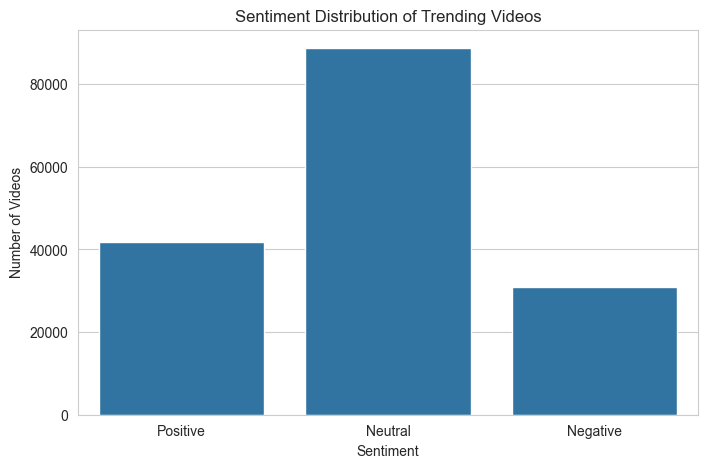

In [22]:
# Visualize sentiment distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Sentiment Distribution of Trending Videos")
plt.xlabel("Sentiment")
plt.ylabel("Number of Videos")

plt.show()

In [23]:
# Extract important keywords using TF-IDF

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

tfidf_matrix = tfidf.fit_transform(df["text"])

keywords = pd.DataFrame({
    "Keyword": tfidf.get_feature_names_out(),
    "Score": tfidf_matrix.sum(axis=0).A1
})

keywords = keywords.sort_values(
    by="Score",
    ascending=False
)

keywords.head(20)

,Keyword,Score
1,2018,14155.205242
15,video,13601.863313
9,music,9519.719628
4,funny,9223.297871
10,new,9219.277000
12,official,8953.695955
11,news,8060.321145
5,la,7899.711896
0,2017,6954.457761
16,vs,6467.518558


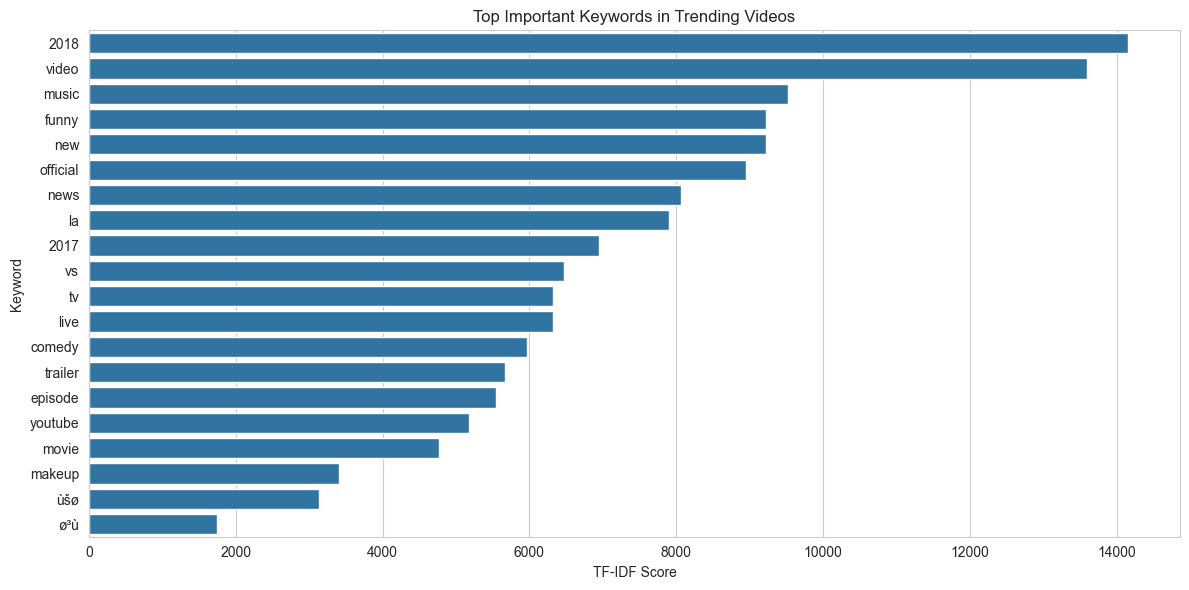

In [24]:
# Plot top keywords

plt.figure(figsize=(12,6))

sns.barplot(
    data=keywords,
    x="Score",
    y="Keyword"
)

plt.title("Top Important Keywords in Trending Videos")
plt.xlabel("TF-IDF Score")
plt.ylabel("Keyword")

plt.tight_layout()
plt.show()

In [25]:
# Prepare daily views for forecasting

time_series = (
    df.groupby("publish_date")["views"]
    .sum()
    .sort_index()
)

time_series = time_series.asfreq("D")

time_series = time_series.fillna(method="ffill")

time_series.head()

publish_date
2006-07-23    258506.0
2006-07-24    258506.0
2006-07-25    258506.0
2006-07-26    258506.0
2006-07-27    258506.0
Freq: D, Name: views, dtype: float64

In [26]:
# Train Exponential Smoothing model

model = ExponentialSmoothing(
    time_series,
    trend="add",
    seasonal=None
)

fit_model = model.fit()

forecast = fit_model.forecast(30)

forecast.head()

2018-06-15    8.784576e+08
2018-06-16    8.784576e+08
2018-06-17    8.784576e+08
2018-06-18    8.784576e+08
2018-06-19    8.784576e+08
Freq: D, dtype: float64

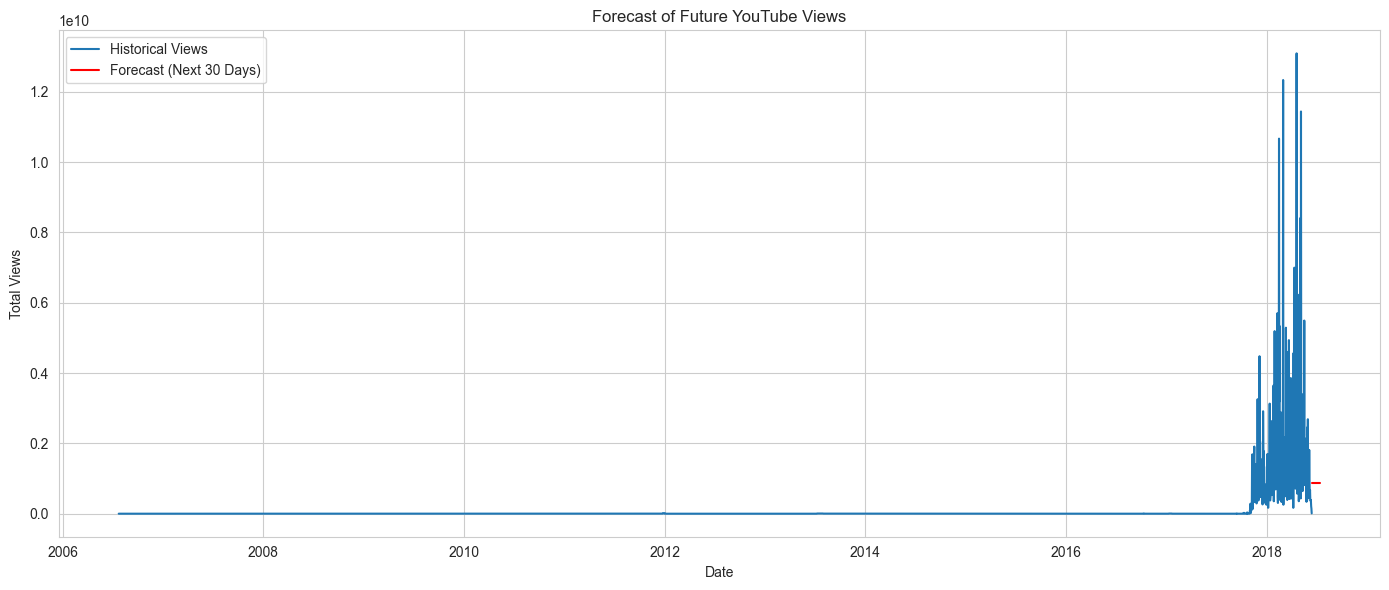

In [27]:
# Plot historical values and forecast

plt.figure(figsize=(14,6))

plt.plot(
    time_series,
    label="Historical Views"
)

plt.plot(
    forecast,
    label="Forecast (Next 30 Days)",
    color="red"
)

plt.title("Forecast of Future YouTube Views")
plt.xlabel("Date")
plt.ylabel("Total Views")

plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# Display important project insights

print("========== PROJECT INSIGHTS ==========\n")

print(f"Total Videos Analysed : {len(df)}")

print(f"Average Views : {int(df['views'].mean())}")

print(f"Average Likes : {int(df['likes'].mean())}")

print(f"Average Comments : {int(df['comment_count'].mean())}")

print("\nTop Trending Channel:")
print(df["channel_title"].value_counts().head(1))

print("\nMost Common Sentiment:")
print(df["sentiment"].value_counts().head(1))

print("\nMost Frequent Category:")
print(df["category_id"].value_counts().head(1))

========== PROJECT INSIGHTS ==========

Total Videos Analysed : 161470
Average Views : 2419854
Average Likes : 65661
Average Comments : 7035

Top Trending Channel:
channel_title
The Late Show with Stephen Colbert    653
Name: count, dtype: int64

Most Common Sentiment:
sentiment
Neutral    88740
Name: count, dtype: int64

Most Frequent Category:
category_id
24    42358
Name: count, dtype: int64


In [29]:
# Final conclusion

print("========== CONCLUSION ==========\n")

print(
    "This project analysed YouTube trending videos using data "
    "preprocessing, exploratory data analysis, natural language "
    "processing and time series forecasting."
)

print(
    "\nThe analysis indicates that user engagement metrics such as "
    "views, likes and comments play an important role in identifying "
    "popular videos."
)

print(
    "\nSentiment analysis and keyword extraction provided additional "
    "insights into trending content, while Exponential Smoothing "
    "was used to forecast future viewing trends."
)

print(
    "\nOverall, the project demonstrates how data science techniques "
    "can be applied to understand and analyse YouTube trending videos."
)

========== CONCLUSION ==========

This project analysed YouTube trending videos using data preprocessing, exploratory data analysis, natural language processing and time series forecasting.

The analysis indicates that user engagement metrics such as views, likes and comments play an important role in identifying popular videos.

Sentiment analysis and keyword extraction provided additional insights into trending content, while Exponential Smoothing was used to forecast future viewing trends.

Overall, the project demonstrates how data science techniques can be applied to understand and analyse YouTube trending videos.
